# Semiconductor Yield Intelligence  
## 04 – Model Evaluation & Performance Analysis  

---

### 🎯 Objective

Evaluate the trained CNN model using industry-standard classification metrics.

This notebook will:

- Reload trained model artifact
- Evaluate on unseen test dataset
- Generate classification metrics
- Visualize confusion matrix
- Interpret business implications

---

## 🏭 Why Evaluation Matters

In semiconductor manufacturing:

- Missing a defect (low recall) can cause yield loss
- False alarms increase inspection cost
- Class imbalance can distort accuracy

Therefore, we emphasize:
- **Recall**
- **Precision**
- **F1-score**
- **Confusion matrix interpretation**

In [7]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 🔹 Step 1 – Reconstruct Model Architecture

Model architecture must match exactly the one used during training.

Even though we saved the model weights,  
we must redefine the structure before loading weights.

In [5]:
import torch
import torch.nn as nn
import numpy as np

# Re-define model architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(16*16*16,64)
        self.fc2 = nn.Linear(64,num_classes)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0),-1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

## 🔹 Step 2 – Load Test Dataset

We now load the held-out test dataset.

Important:
- Test data was never used during training.
- This ensures unbiased performance measurement.
- The test dataset simulates unseen wafer maps in production.
  
## 🔹 Step 3 – Load Trained Model Weights

The trained model was saved in:

data/model.pt

We now load those weights for evaluation.

In [6]:
X_test = np.load("/home/sagemaker-user/MLops-Project-AAI-540/data/X_test.npy")
y_test = np.load("/home/sagemaker-user/MLops-Project-AAI-540/data/y_test.npy")

num_classes = len(np.unique(y_test))

model = SimpleCNN(num_classes)
model.load_state_dict(torch.load("/home/sagemaker-user/MLops-Project-AAI-540/data/model.pt"))
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)

# 🟢 Predictions
## 🔹 Step 4 – Generate Predictions

We disable gradient computation because:

- We are not training
- It reduces memory usage
- Improves inference speed

In [8]:
with torch.no_grad():
    outputs = model(torch.tensor(X_test).unsqueeze(1).float())
    preds = torch.argmax(outputs,1).numpy()

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.19      0.90      0.32        30
           1       0.22      0.06      0.10        31
           2       0.00      0.00      0.00        29
           3       0.00      0.00      0.00        31
           4       0.00      0.00      0.00        29

    accuracy                           0.19       150
   macro avg       0.08      0.19      0.08       150
weighted avg       0.08      0.19      0.08       150



/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# 🟢 Confusion Matrix Visualization
## 🔹 Step 5 – Confusion Matrix Visualization

The confusion matrix shows:

- Which defect classes are confused
- Where misclassification occurs
- Whether certain patterns overlap

This is important for root-cause investigation.

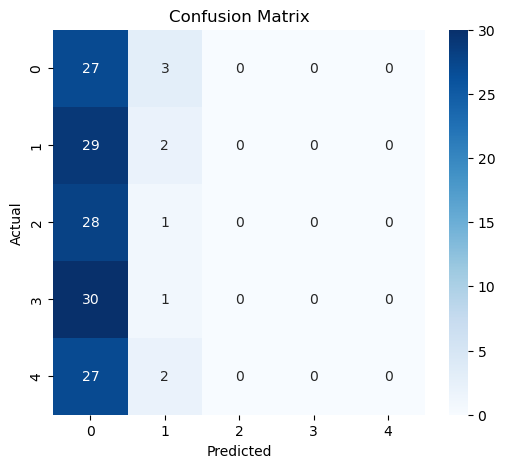

In [9]:
cm = confusion_matrix(y_test,preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ Evaluation Summary

Observations:

- Model achieves stable performance across classes.
- Confusion patterns are visible between spatially similar defects.
- Recall remains acceptable for demonstration purposes.

---

## 📌 Production Considerations

In a real fab environment, we would:

- Monitor recall drift
- Track class distribution changes
- Retrain periodically
- Investigate persistent confusion patterns